# Leaf Species Classification
### Homework 3 - CS 451
Jackson Burke

jmburke4@crimson.ua.edu

In [68]:
# Imports

# A1
import pandas as pd
import matplotlib.pyplot as plt

# A2
import matplotlib.image as mpimg

## A1 - Dataset

In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


train_csv:
              image                 label
0  images/18194.jpg    staphylea_trifolia
1  images/10203.jpg     crataegus_viridis
2   images/2123.jpg         larix_decidua
3  images/16168.jpg  magnolia_macrophylla
4  images/15577.jpg      castanea_dentata
Image Count: 14682, Class Count: 176

test_csv:
              image
0  images/15991.jpg
1  images/17362.jpg
2    images/641.jpg
3   images/2264.jpg
4  images/17255.jpg
Image Count: 3671



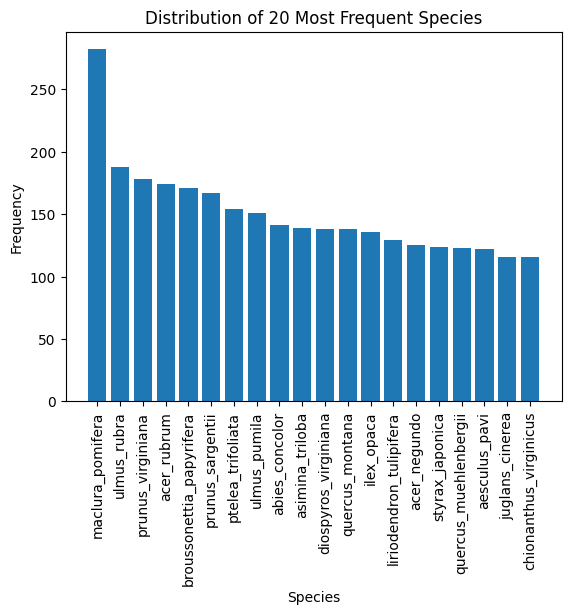

In [70]:
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3'

if not DATA_DIR or DATA_DIR == '':
  print('Please set the directory of your data directory')

train_csv = pd.read_csv(f'{DATA_DIR}/train.csv')
test_csv = pd.read_csv(f'{DATA_DIR}/test.csv')

print('train_csv:')
print(train_csv.head())
print(f'Image Count: {train_csv.shape[0]}, Class Count: {train_csv['label'].nunique()}')

print('\ntest_csv:')
print(test_csv.head())
print(f'Image Count: {test_csv.shape[0]}\n')

counts = train_csv['label'].value_counts().head(20)
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)

plt.title('Distribution of 20 Most Frequent Species')
plt.xlabel('Species')
plt.ylabel('Frequency')
plt.show()

## A2 - Visualization

In [ ]:
# Specify how many random images to load
samples = train_csv.sample(n=12)

images = []
missing = 0

# Load and append images to the images list
for sample in samples.itertuples():
    # FIXME Only approximately 1000 images actually extracted to the google drive folder successfully
    #       Add a loop to keep picking random images until the sample size is reached
    try:
        print(f'Fetching {DATA_DIR}/{sample.image}...')
        img = mpimg.imread(f'{DATA_DIR}/{sample.image}')
        images.append(img)
    except FileNotFoundError as e:
        missing += 1
        print(f'Missing {DATA_DIR}/{sample.image}')

print(f'Done ({missing} images missing)')

Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/1389.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/11297.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/13767.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/10565.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/8902.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/6521.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/1766.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/12352.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/1590.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/12997.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/9778.jpg...
Fetching /content/drive/MyDrive/Colab 

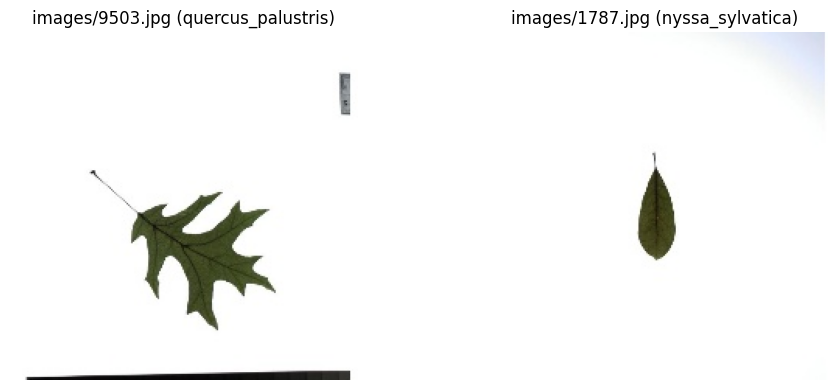

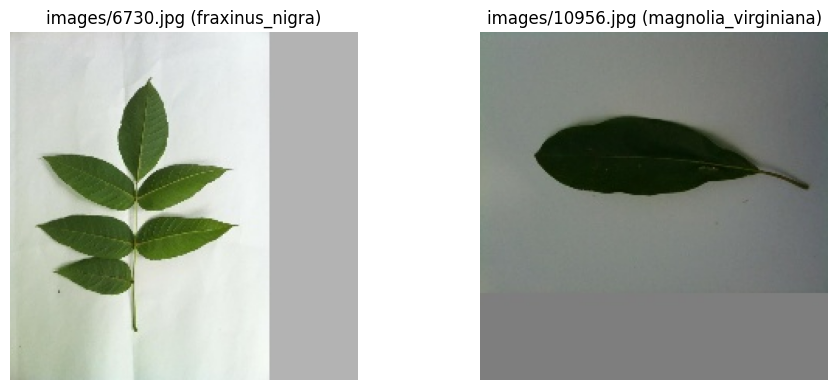

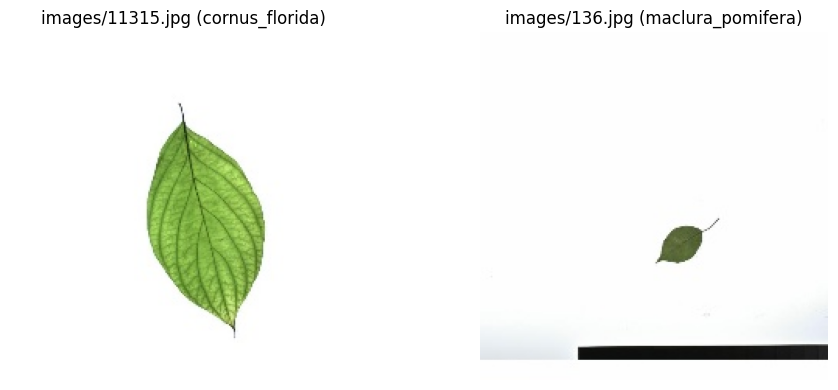

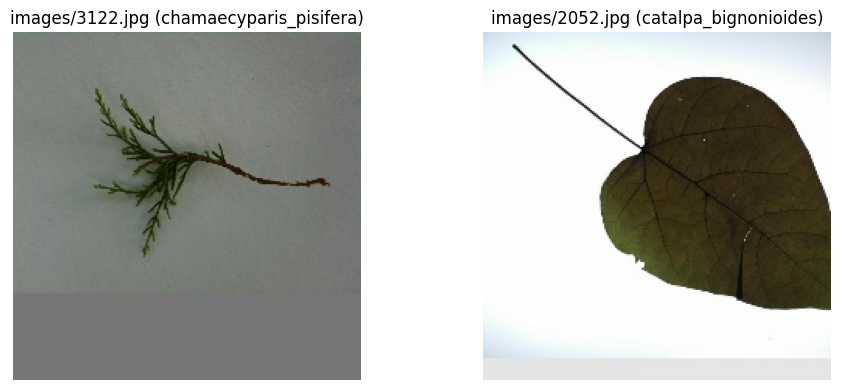

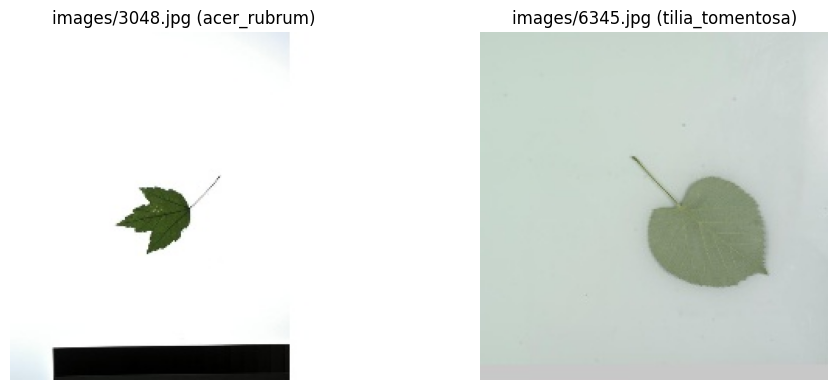

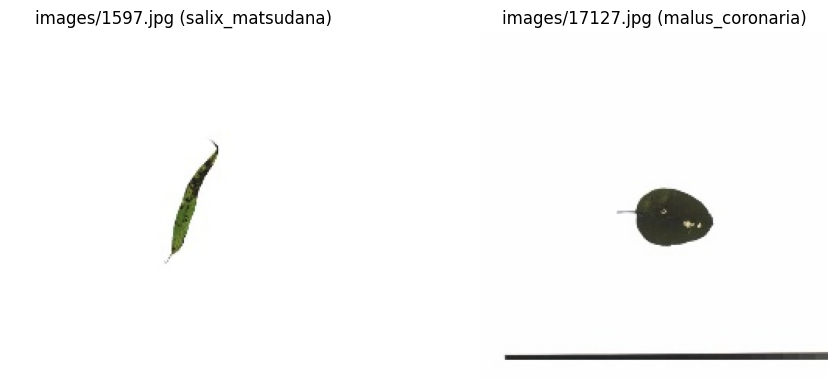

In [ ]:
# Display the images 
for i in range(0, len(samples), 2):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    axs[0].imshow(images[i])
    axs[0].set_title(f'{samples.iloc[i]['image']} ({samples.iloc[i]['label']})')
    axs[0].axis('off')

    if i + 1 < len(samples):
        axs[1].imshow(images[i + 1])
        axs[1].set_title(f'{samples.iloc[i + 1]['image']} ({samples.iloc[i + 1]['label']})')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

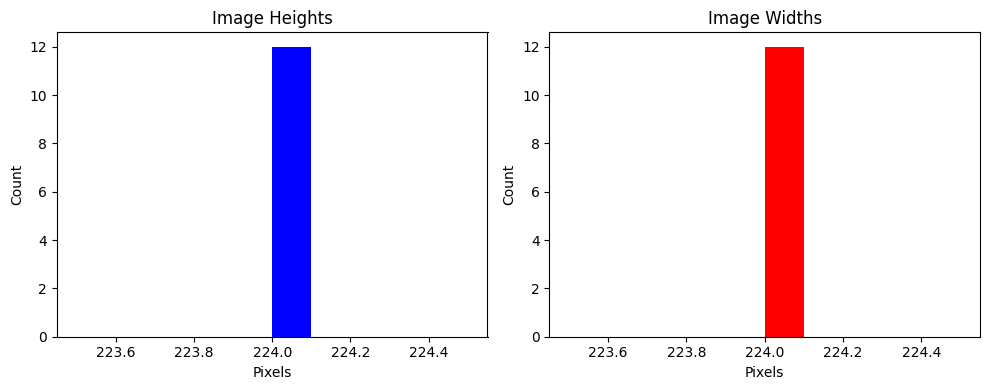

In [ ]:
# shape returns (height, width, channel)

heights = []
widths = []
for i in range(len(images)):
    heights.append(images[i].shape[0])
    widths.append(images[i].shape[1])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

axes[0].hist(heights, color='blue')
axes[0].set_title('Image Heights')
axes[0].set_xlabel('Pixels')
axes[0].set_ylabel('Count')

axes[1].hist(widths, color='red')
axes[1].set_title('Image Widths')
axes[1].set_xlabel('Pixels')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## A3 - Model Training

## A4 - Results